In [12]:
# bvh_viewer.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from bvh import Bvh
from pathlib import Path

BVH_PATH = "/Users/martinjaramillo/Documents/Unreal+Rokoko/v5/Untitled.bvh"  # <-- change

try:
    from bvh import Bvh
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "bvh-python"])
    from bvh import Bvh

# ---- math helpers ----
def Rx(a):
    c,s = np.cos(a), np.sin(a)
    return np.array([[1,0,0],[0,c,-s],[0,s,c]], dtype=np.float64)
def Ry(a):
    c,s = np.cos(a), np.sin(a)
    return np.array([[c,0,s],[0,1,0],[-s,0,c]], dtype=np.float64)
def Rz(a):
    c,s = np.cos(a), np.sin(a)
    return np.array([[c,-s,0],[s,c,0],[0,0,1]], dtype=np.float64)

def euler_to_R(angles_deg, order_tokens):
    R = np.eye(3, dtype=np.float64)
    for tok, ang in zip(order_tokens, angles_deg):
        ax = tok[0].upper()
        a = np.deg2rad(ang)
        R = R @ {'X':Rx,'Y':Ry,'Z':Rz}[ax](a)
    return R

def mat_to_quat_xyzw(R):
    m00,m01,m02 = R[0]; m10,m11,m12 = R[1]; m20,m21,m22 = R[2]
    t = m00 + m11 + m22
    if t > 0:
        w = np.sqrt(1.0 + t) * 0.5; f = 0.25 / w
        x = (m21 - m12) * f; y = (m02 - m20) * f; z = (m10 - m01) * f
    elif m00 > m11 and m00 > m22:
        x = np.sqrt(1.0 + m00 - m11 - m22) * 0.5; f = 0.25 / x
        y = (m01 + m10) * f; z = (m02 + m20) * f; w = (m21 - m12) * f
    elif m11 > m22:
        y = np.sqrt(1.0 - m00 + m11 - m22) * 0.5; f = 0.25 / y
        x = (m01 + m10) * f; z = (m12 + m21) * f; w = (m02 - m20) * f
    else:
        z = np.sqrt(1.0 - m00 - m11 + m22) * 0.5; f = 0.25 / z
        x = (m02 + m20) * f; y = (m12 + m21) * f; w = (m10 - m01) * f
    q = np.array([x,y,z,w], dtype=np.float64)
    n = np.linalg.norm(q)
    return q if n == 0 else q / n

# ---- robust BVH parse (skips End Sites) ----
def parse_bvh_safe(path):
    b = Bvh(Path(path).read_text())

    nodes = []
    for n in b.get_joints():
        v = getattr(n, "value", [])
        tkn = (v[0] if len(v)>0 else "").upper()
        name = (v[1] if len(v)>1 else None)
        if tkn in ("ROOT","JOINT") and name:
            nodes.append(n)

    joints = [n.value[1] for n in nodes]
    name_to_idx = {n:i for i,n in enumerate(joints)}

    parents = np.full(len(joints), -1, dtype=int)
    offsets = np.zeros((len(joints),3), dtype=np.float64)
    rot_orders = [None]*len(joints)
    has_root_pos = np.zeros(len(joints), dtype=bool)

    def get_offsets(node):
        # try attribute, else token dict, else zeros
        try:
            off = node.offsets
            return np.array([float(off[0]), float(off[1]), float(off[2])], dtype=np.float64)
        except Exception:
            try:
                tok = node["OFFSET"]
                return np.array([float(tok[0]), float(tok[1]), float(tok[2])], dtype=np.float64)
            except Exception:
                return np.zeros(3, dtype=np.float64)

    for n in nodes:
        i = name_to_idx[n.value[1]]
        par = getattr(n, "parent", None)
        if par is not None:
            pv = getattr(par, "value", [])
            if len(pv)>1 and pv[0].upper() in ("ROOT","JOINT"):
                pname = pv[1]
                if pname in name_to_idx:
                    parents[i] = name_to_idx[pname]

        offsets[i] = get_offsets(n)

        chans = b.joint_channels(joints[i])  # list of channel names
        rot_order = [c for c in chans if "rotation" in c.lower()]
        pos_chans = [c for c in chans if "position" in c.lower()]
        rot_orders[i] = rot_order
        has_root_pos[i] = (parents[i] == -1 and len(pos_chans) == 3)

    return b, joints, parents, offsets, rot_orders, has_root_pos, b.nframes, b.frame_time

def frame_channels(b, joint_name, f_idx):
    chans = b.joint_channels(joint_name)
    # IMPORTANT: pass 'chans' into frame_joint_channels for this API variant
    vals = [float(v) for v in b.frame_joint_channels(f_idx, joint_name, chans)]
    return chans, vals

# ---- extract ----
b, joints, parents, offsets, rot_orders, has_root_pos, n_frames, dt = parse_bvh_safe(BVH_PATH)
J = len(joints)

local_quats = np.zeros((n_frames, J, 4), dtype=np.float64)   # xyzw
root_translation = np.zeros((n_frames, 3), dtype=np.float64) # only filled for root joint

for f in range(n_frames):
    for j_idx, jname in enumerate(joints):
        chans, vals = frame_channels(b, jname, f)
        pos = np.zeros(3, dtype=np.float64)
        rot_vals = []
        for c, v in zip(chans, vals):
            if "position" in c.lower():
                if c[0]=='X': pos[0]=v
                elif c[0]=='Y': pos[1]=v
                elif c[0]=='Z': pos[2]=v
            elif "rotation" in c.lower():
                rot_vals.append(v)

        order = rot_orders[j_idx] or []
        R = euler_to_R(rot_vals, order) if order else np.eye(3, dtype=np.float64)
        local_quats[f, j_idx] = mat_to_quat_xyzw(R)
        if has_root_pos[j_idx]:
            root_translation[f] = pos

np.savez_compressed(
    "bvh_dataset.npz",
    joint_names=np.array(joints, dtype=object),
    parents=parents,
    offsets=offsets,
    rot_order=np.array(rot_orders, dtype=object),
    frame_time=np.float64(dt),
    local_quat_xyzw=local_quats,
    root_translation=root_translation,
)

print("✅ Extracted BVH")
print(f"Frames: {n_frames}, Joints: {J}, FPS: {1.0/dt:.3f}")
print("Saved → bvh_dataset.npz")

✅ Extracted BVH
Frames: 250, Joints: 65, FPS: 30.000
Saved → bvh_dataset.npz


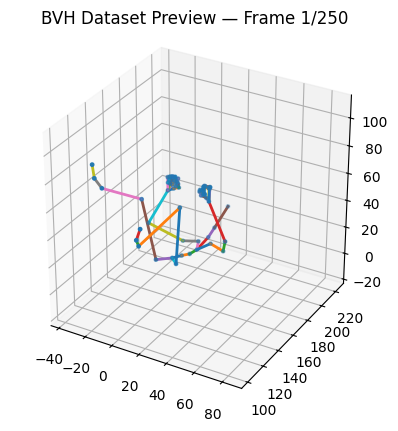

Saved animation: /Users/martinjaramillo/Documents/Unreal+Rokoko/v5/bvh_preview.gif


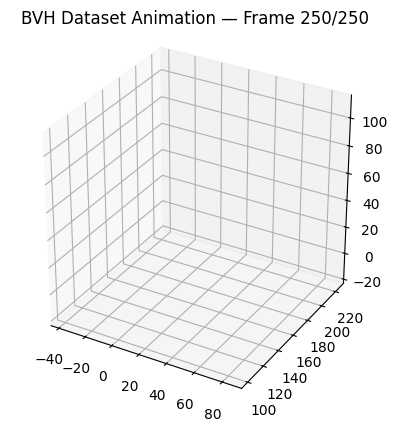

In [15]:
# --- VISUALIZE EXISTING DATASET (set your path) ---
DATA_PATH = "/Users/martinjaramillo/Documents/Unreal+Rokoko/v5/bvh_dataset.npz"  # <-- put your file path here

import numpy as np, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from pathlib import Path

data = np.load(DATA_PATH, allow_pickle=True)
joint_names = data["joint_names"]; parents = data["parents"]; offsets = data["offsets"]
local_quats = data["local_quat_xyzw"]; root_t = data["root_translation"]
dt = float(data["frame_time"]); F, J, _ = local_quats.shape
edges = [(p,i) for i,p in enumerate(parents) if p != -1]

def quat_to_R_xyzw(q):
    x,y,z,w = q; n=(x*x+y*y+z*z+w*w)**0.5
    if n==0: return np.eye(3)
    x,y,z,w = x/n,y/n,z/n,w/n
    xx,yy,zz=x*x,y*y,z*z; xy, xz, yz = x*y, x*z, y*z; wx, wy, wz = w*x, w*y, w*z
    return np.array([[1-2*(yy+zz), 2*(xy-wz), 2*(xz+wy)],
                     [2*(xy+wz), 1-2*(xx+zz), 2*(yz-wx)],
                     [2*(xz-wy), 2*(yz+wx), 1-2*(xx+yy)]])

def fk_world_positions(f_idx):
    Pw = np.zeros((J,3)); Rw = np.zeros((J,3,3))
    for j in range(J):
        Rloc = quat_to_R_xyzw(local_quats[f_idx, j]); tloc = offsets[j]
        p = parents[j]
        if p == -1:
            Rw[j] = Rloc; Pw[j] = root_t[f_idx] + tloc
        else:
            Rw[j] = Rw[p] @ Rloc; Pw[j] = Pw[p] + (Rw[p] @ tloc)
    return Pw

# bounds from a few frames
sample_frames = [0, max(0,F//3-1), max(0,2*F//3-1), F-1]
pts = np.vstack([fk_world_positions(f) for f in sample_frames])
mn, mx = pts.min(0), pts.max(0); span = max(1e-6, (mx-mn).max())

# static preview
P0 = fk_world_positions(0)
fig = plt.figure(); ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect([1,1,1])
ax.set_xlim(mn[0]-0.1*span, mn[0]+0.9*span)
ax.set_ylim(mn[1]-0.1*span, mn[1]+0.9*span)
ax.set_zlim(mn[2]-0.1*span, mn[2]+0.9*span)
for p,i in edges:
    xs,ys,zs = [P0[p,0],P0[i,0]],[P0[p,1],P0[i,1]],[P0[p,2],P0[i,2]]
    ax.plot(xs,ys,zs,lw=2)
ax.scatter(P0[:,0],P0[:,1],P0[:,2],s=6)
ax.set_title(f"BVH Dataset Preview — Frame 1/{F}")
plt.show()

# animation → GIF
fig2 = plt.figure(); ax2 = fig2.add_subplot(111, projection='3d')
ax2.set_box_aspect([1,1,1])
ax2.set_xlim(mn[0]-0.1*span, mn[0]+0.9*span)
ax2.set_ylim(mn[1]-0.1*span, mn[1]+0.9*span)
ax2.set_zlim(mn[2]-0.1*span, mn[2]+0.9*span)
lines = [ax2.plot([],[],[],lw=2)[0] for _ in edges]
sc = ax2.scatter([],[],[],s=6)
def init(): 
    for ln in lines: ln.set_data([],[]); ln.set_3d_properties([]); 
    sc._offsets3d = ([],[],[]); 
    return lines+[sc]
def update(f):
    P = fk_world_positions(f)
    for ln,(p,i) in zip(lines,edges):
        xs,ys,zs=[P[p,0],P[i,0]],[P[p,1],P[i,1]],[P[p,2],P[i,2]]
        ln.set_data(xs,ys); ln.set_3d_properties(zs)
    sc._offsets3d = (P[:,0],P[:,1],P[:,2])
    ax2.set_title(f"BVH Dataset Animation — Frame {f+1}/{F}")
    return lines+[sc]
ani = FuncAnimation(fig2, update, frames=F, init_func=init, interval=max(5,int(1000*dt)), blit=False, repeat=True)

# Save a GIF you can download from the notebook
out_path = Path("/Users/martinjaramillo/Documents/Unreal+Rokoko/v5/bvh_preview.gif")
try:
    ani.save(out_path, writer=PillowWriter(fps=max(1,int(1.0/dt))))
    print(f"Saved animation: {out_path}")
except Exception as e:
    print("Could not save GIF:", e)

In [24]:
# --- BVH dataset (.npz) → Pandas DataFrame ---
import numpy as np
import pandas as pd
from pathlib import Path

# set your dataset path
DATA_PATH = "bvh_dataset.npz"  # change if needed

# load dataset
data = np.load(DATA_PATH, allow_pickle=True)
joint_names = data["joint_names"]
local_quats = data["local_quat_xyzw"]   # shape [frames, joints, 4]
root_translation = data["root_translation"]  # shape [frames, 3]
dt = float(data["frame_time"])

F, J, _ = local_quats.shape
fps = round(1.0 / dt, 3)

print(f"Loaded dataset: {F} frames, {J} joints, ~{fps} FPS")

# flatten into table
rows = []
for f in range(F):
    time_sec = f * dt
    for j_idx, jname in enumerate(joint_names):
        qx, qy, qz, qw = local_quats[f, j_idx]
        rows.append({
            "frame": f,
            "time": time_sec,
            "joint": jname,
            "quat_x": qx,
            "quat_y": qy,
            "quat_z": qz,
            "quat_w": qw,
            "root_tx": root_translation[f, 0],
            "root_ty": root_translation[f, 1],
            "root_tz": root_translation[f, 2],
        })

df = pd.DataFrame(rows)

# preview
display(df.head())

# optional: save
out_path = Path("bvh_dataset.csv")
df.to_csv(out_path, index=False)
print(f"✅ Saved DataFrame → {out_path}")
print(f"Columns: {list(df.columns)}")

Loaded dataset: 250 frames, 65 joints, ~30.0 FPS


,frame,time,joint,quat_x,quat_y,quat_z,quat_w,root_tx,root_ty,root_tz
0,0,0.0,mixamorig:Hips,-0.153790,-0.068295,-0.057196,0.984080,-0.516523,64.068367,1.35367
1,0,0.0,mixamorig:Spine,0.052388,0.024654,0.034166,0.997738,-0.516523,64.068367,1.35367
2,0,0.0,mixamorig:Spine1,0.093505,0.003136,0.021353,0.995385,-0.516523,64.068367,1.35367
3,0,0.0,mixamorig:Spine2,0.093390,0.003599,0.021786,0.995385,-0.516523,64.068367,1.35367
4,0,0.0,mixamorig:Neck,-0.035678,0.005798,-0.006457,0.999326,-0.516523,64.068367,1.35367


✅ Saved DataFrame → bvh_dataset.csv
Columns: ['frame', 'time', 'joint', 'quat_x', 'quat_y', 'quat_z', 'quat_w', 'root_tx', 'root_ty', 'root_tz']


In [22]:
df[df["joint"].str.contains("leg", case=False, na=False)]

,frame,time,joint,quat_x,quat_y,quat_z,quat_w,root_tx,root_ty,root_tz
55,0,0.000000,mixamorig:RightUpLeg,-0.570256,-0.045444,-0.003970,0.820200,-0.516523,64.068367,1.353670
56,0,0.000000,mixamorig:RightLeg,0.421828,-0.003426,-0.002603,0.906665,-0.516523,64.068367,1.353670
60,0,0.000000,mixamorig:LeftUpLeg,-0.570507,0.067878,0.104775,0.811749,-0.516523,64.068367,1.353670
61,0,0.000000,mixamorig:LeftLeg,0.721465,0.055173,0.064752,0.687205,-0.516523,64.068367,1.353670
120,1,0.033333,mixamorig:RightUpLeg,-0.570831,-0.045314,-0.003898,0.819807,-0.512158,64.068703,1.342978
...,...,...,...,...,...,...,...,...,...,...
16181,248,8.266584,mixamorig:LeftLeg,0.721465,0.055173,0.064752,0.687205,-0.516523,64.068367,1.353670
16240,249,8.299917,mixamorig:RightUpLeg,-0.570256,-0.045444,-0.003970,0.820200,-0.516523,64.068367,1.353670
16241,249,8.299917,mixamorig:RightLeg,0.421828,-0.003426,-0.002603,0.906665,-0.516523,64.068367,1.353670
16245,249,8.299917,mixamorig:LeftUpLeg,-0.570507,0.067878,0.104775,0.811749,-0.516523,64.068367,1.353670


In [20]:
df["joint"].unique()

array(['mixamorig:Hips', 'mixamorig:Spine', 'mixamorig:Spine1',
       'mixamorig:Spine2', 'mixamorig:Neck', 'mixamorig:Head',
       'mixamorig:HeadTop_End', 'mixamorig:RightShoulder',
       'mixamorig:RightArm', 'mixamorig:RightForeArm',
       'mixamorig:RightHand', 'mixamorig:RightHandThumb1',
       'mixamorig:RightHandThumb2', 'mixamorig:RightHandThumb3',
       'mixamorig:RightHandThumb4', 'mixamorig:RightHandIndex1',
       'mixamorig:RightHandIndex2', 'mixamorig:RightHandIndex3',
       'mixamorig:RightHandIndex4', 'mixamorig:RightHandMiddle1',
       'mixamorig:RightHandMiddle2', 'mixamorig:RightHandMiddle3',
       'mixamorig:RightHandMiddle4', 'mixamorig:RightHandRing1',
       'mixamorig:RightHandRing2', 'mixamorig:RightHandRing3',
       'mixamorig:RightHandRing4', 'mixamorig:RightHandPinky1',
       'mixamorig:RightHandPinky2', 'mixamorig:RightHandPinky3',
       'mixamorig:RightHandPinky4', 'mixamorig:LeftShoulder',
       'mixamorig:LeftArm', 'mixamorig:LeftForeArm', 

In [33]:
# --- Install once (uncomment if needed) ---
# !pip install bvh pandas numpy

from bvh import Bvh
import pandas as pd
import numpy as np

def bvh_to_dataframe_euler(bvh_path: str, repeat_root_translation: bool = True) -> pd.DataFrame:
    """
    Load a BVH file and return a DataFrame with Euler rotations in degrees, ready for Unreal.

    Output columns:
      frame | time | joint | pitch_deg | yaw_deg | roll_deg | root_tx | root_ty | root_tz

    Notes:
    - BVH stores Euler angles, not quaternions. We read them directly.
    - We map BVH channels to Unreal-friendly names:
        pitch_deg = Xrotation (rotation around local X)
        yaw_deg   = Yrotation (rotation around local Y)
        roll_deg  = Zrotation (rotation around local Z)
    - Root translation (usually on the hips) is repeated on every row if repeat_root_translation=True.
    """
    with open(bvh_path, "r") as f:
        mocap = Bvh(f.read())

    frame_time = float(mocap.frame_time)
    n_frames   = int(mocap.nframes)
    joints     = mocap.get_joints_names()

    # Detect which joint has translation channels (usually the root/hips)
    # We'll use its translation as the "root_*" values.
    root_joint_with_pos = None
    for j in joints:
        chans = mocap.joint_channels(j)
        if any(c.endswith("position") for c in chans):
            root_joint_with_pos = j
            break

    records = []

    for f_idx in range(n_frames):
        t_sec = f_idx * frame_time

        # Cache root translation, if present
        root_tx = root_ty = root_tz = 0.0
        if root_joint_with_pos is not None:
            chans_root = mocap.joint_channels(root_joint_with_pos)
            vals_root  = mocap.frame_joint_channels(f_idx, root_joint_with_pos, chans_root)
            chmap_root = {c: float(v) for c, v in zip(chans_root, vals_root)}
            root_tx = chmap_root.get("Xposition", 0.0)
            root_ty = chmap_root.get("Yposition", 0.0)
            root_tz = chmap_root.get("Zposition", 0.0)

        for j in joints:
            chans = mocap.joint_channels(j)
            vals  = mocap.frame_joint_channels(f_idx, j, chans)
            chmap = {c: float(v) for c, v in zip(chans, vals)}

            # Euler angles in degrees straight from BVH (order-safe by channel name)
            pitch_deg = chmap.get("Xrotation", 0.0)  # rotation around local X
            yaw_deg   = chmap.get("Yrotation", 0.0)  # rotation around local Y
            roll_deg  = chmap.get("Zrotation", 0.0)  # rotation around local Z

            # Repeat root translation on every row (helps downstream pipelines)
            rtx = root_tx if repeat_root_translation else (chmap.get("Xposition", 0.0) if j == root_joint_with_pos else 0.0)
            rty = root_ty if repeat_root_translation else (chmap.get("Yposition", 0.0) if j == root_joint_with_pos else 0.0)
            rtz = root_tz if repeat_root_translation else (chmap.get("Zposition", 0.0) if j == root_joint_with_pos else 0.0)

            records.append([
                f_idx, t_sec, j, pitch_deg, yaw_deg, roll_deg, rtx, rty, rtz
            ])

    df = pd.DataFrame(records, columns=[
        "frame", "time", "joint", "pitch_deg", "yaw_deg", "roll_deg",
        "root_tx", "root_ty", "root_tz"
    ])
    return df

# ---- Example usage ----
bvh_path = "/Users/martinjaramillo/Documents/Unreal+Rokoko/v5/Driving.fbx"
df = bvh_to_dataframe_euler(bvh_path)
display(df.head())
df.to_csv("driving.csv", index=False)

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xfe in position 27: invalid start byte

In [29]:
df

,frame,time,joint,pitch_deg,yaw_deg,roll_deg,root_tx,root_ty,root_tz
0,0,0.000000,mixamorig:Hips,0.000021,0.000003,-0.000113,0.000006,104.27047,1.554256
1,0,0.000000,mixamorig:Spine,0.000002,-0.000003,0.000084,0.000006,104.27047,1.554256
2,0,0.000000,mixamorig:Spine1,-0.000000,0.000000,-0.000000,0.000006,104.27047,1.554256
3,0,0.000000,mixamorig:Spine2,-0.000000,0.000000,-0.000000,0.000006,104.27047,1.554256
4,0,0.000000,mixamorig:Neck,0.000000,-0.000000,-0.000000,0.000006,104.27047,1.554256
...,...,...,...,...,...,...,...,...,...
16245,249,8.299917,mixamorig:LeftUpLeg,-0.074517,-0.000003,0.000081,0.000006,104.27047,1.554256
16246,249,8.299917,mixamorig:LeftLeg,0.148830,0.000002,0.000000,0.000006,104.27047,1.554256
16247,249,8.299917,mixamorig:LeftFoot,-0.074309,0.000000,-0.000002,0.000006,104.27047,1.554256
16248,249,8.299917,mixamorig:LeftToeBase,0.000005,-0.000000,-0.000000,0.000006,104.27047,1.554256


In [34]:
# --- Install dependencies once ---
# !pip install bvh pandas numpy

from bvh import Bvh
import pandas as pd

# --- Input / Output paths ---
bvh_path = "/Users/martinjaramillo/Documents/Unreal+Rokoko/v5/Untitled.bvh"          # 👈 replace with your BVH file path
out_csv  = "driving.csv"   # 👈 where to save the CSV

# --- Read BVH ---
with open(bvh_path, 'r') as f:
    mocap = Bvh(f.read())

frame_time = float(mocap.frame_time)
n_frames = int(mocap.nframes)
joints = mocap.get_joints_names()

# Detect which joint has translation (usually Hips)
root_joint = None
for j in joints:
    chans = mocap.joint_channels(j)
    if any("position" in c for c in chans):
        root_joint = j
        break

records = []
for frame in range(n_frames):
    time_sec = frame * frame_time

    # Root translation
    root_tx = root_ty = root_tz = 0.0
    if root_joint:
        chans_root = mocap.joint_channels(root_joint)
        vals_root = mocap.frame_joint_channels(frame, root_joint, chans_root)
        chmap_root = {c: float(v) for c, v in zip(chans_root, vals_root)}
        root_tx = chmap_root.get("Xposition", 0.0)
        root_ty = chmap_root.get("Yposition", 0.0)
        root_tz = chmap_root.get("Zposition", 0.0)

    # Extract rotations for all joints
    for j in joints:
        chans = mocap.joint_channels(j)
        vals = mocap.frame_joint_channels(frame, j, chans)
        chmap = {c: float(v) for c, v in zip(chans, vals)}

        pitch_deg = chmap.get("Xrotation", 0.0)
        yaw_deg   = chmap.get("Yrotation", 0.0)
        roll_deg  = chmap.get("Zrotation", 0.0)

        # Repeat root translation on all joints (for easier Unreal streaming)
        records.append([
            frame, time_sec, j,
            pitch_deg, yaw_deg, roll_deg,
            root_tx, root_ty, root_tz
        ])

# --- Build DataFrame ---
df = pd.DataFrame(records, columns=[
    "frame", "time", "joint",
    "pitch_deg", "yaw_deg", "roll_deg",
    "root_tx", "root_ty", "root_tz"
])

# --- Save CSV ---
df.to_csv(out_csv, index=False)
print(f"✅ Saved {len(df)} rows ({n_frames} frames, {len(joints)} joints) → {out_csv}")

# --- Preview ---
df.head(10)

✅ Saved 16250 rows (250 frames, 65 joints) → driving.csv


,frame,time,joint,pitch_deg,yaw_deg,roll_deg,root_tx,root_ty,root_tz
0,0,0.0,mixamorig:Hips,-18.218237,-6.708780,-7.729635,-0.516523,64.068367,1.35367
1,0,0.0,mixamorig:Spine,5.911846,3.025216,3.766260,-0.516523,64.068367,1.35367
2,0,0.0,mixamorig:Spine1,10.720749,0.586488,2.402822,-0.516523,64.068367,1.35367
3,0,0.0,mixamorig:Spine2,10.706152,0.643692,2.447337,-0.516523,64.068367,1.35367
4,0,0.0,mixamorig:Neck,-4.085091,0.690325,-0.715833,-0.516523,64.068367,1.35367
5,0,0.0,mixamorig:Head,-12.557263,1.524185,3.744502,-0.516523,64.068367,1.35367
6,0,0.0,mixamorig:HeadTop_End,0.000000,0.000000,0.000000,-0.516523,64.068367,1.35367
7,0,0.0,mixamorig:RightShoulder,3.349714,13.625703,10.892394,-0.516523,64.068367,1.35367
8,0,0.0,mixamorig:RightArm,-22.863392,27.056130,21.646179,-0.516523,64.068367,1.35367
9,0,0.0,mixamorig:RightForeArm,-0.000422,82.839594,0.000490,-0.516523,64.068367,1.35367


In [38]:
# --- Install once (if needed) ---
# !pip install bvh pandas numpy

from bvh import Bvh
import pandas as pd

# --- Input / Output paths ---
bvh_path = "/Users/martinjaramillo/Documents/Unreal+Rokoko/v5/Untitled.bvh"          # 👈 replace with your BVH file path
out_csv  = "driving.csv"   # 👈 where to save the CSV


# --- Read BVH ---
with open(bvh_path, 'r') as f:
    mocap = Bvh(f.read())

frame_time = float(mocap.frame_time)
n_frames   = int(mocap.nframes)
joints     = mocap.get_joints_names()

# Detect which joint has translation (usually Hips)
root_joint = None
for j in joints:
    chans = mocap.joint_channels(j)
    if any("position" in c for c in chans):
        root_joint = j
        break

records = []
for frame in range(n_frames):
    time_sec = frame * frame_time

    # Root translation (repeat for convenience)
    root_tx = root_ty = root_tz = 0.0
    if root_joint:
        chans_root = mocap.joint_channels(root_joint)
        vals_root  = mocap.frame_joint_channels(frame, root_joint, chans_root)
        chmap_root = {c: float(v) for c, v in zip(chans_root, vals_root)}
        root_tx = chmap_root.get("Xposition", 0.0)
        root_ty = chmap_root.get("Yposition", 0.0)
        root_tz = chmap_root.get("Zposition", 0.0)

    # Extract rotations for all joints with BVH→Unreal axis remap:
    # Unreal: Pitch(X) ← BVH Zrotation, Yaw(Y) ← BVH Yrotation, Roll(Z) ← BVH Xrotation
    for j in joints:
        chans = mocap.joint_channels(j)
        vals  = mocap.frame_joint_channels(frame, j, chans)
        chmap = {c: float(v) for c, v in zip(chans, vals)}

        z_deg = chmap.get("Zrotation", 0.0)  # Unreal X
        y_deg   = chmap.get("Yrotation", 0.0)  # Unreal Y
        x_deg  = chmap.get("Xrotation", 0.0)  # Unreal Z

        records.append([
            frame, time_sec, j,
            x_deg, y_deg, z_deg,
            root_tx, root_ty, root_tz
        ])

# --- Build DataFrame & Save ---
df = pd.DataFrame(records, columns=[
    "frame", "time", "joint",
    "x_deg", "y_deg", "z_deg",
    "root_tx", "root_ty", "root_tz"
])
df.to_csv(out_csv, index=False)
print(f"✅ Saved {len(df)} rows ({n_frames} frames, {len(joints)} joints) → {out_csv}")

# Preview
df.head(10)

✅ Saved 16250 rows (250 frames, 65 joints) → driving.csv


,frame,time,joint,x_deg,y_deg,z_deg,root_tx,root_ty,root_tz
0,0,0.0,mixamorig:Hips,-18.218237,-6.708780,-7.729635,-0.516523,64.068367,1.35367
1,0,0.0,mixamorig:Spine,5.911846,3.025216,3.766260,-0.516523,64.068367,1.35367
2,0,0.0,mixamorig:Spine1,10.720749,0.586488,2.402822,-0.516523,64.068367,1.35367
3,0,0.0,mixamorig:Spine2,10.706152,0.643692,2.447337,-0.516523,64.068367,1.35367
4,0,0.0,mixamorig:Neck,-4.085091,0.690325,-0.715833,-0.516523,64.068367,1.35367
5,0,0.0,mixamorig:Head,-12.557263,1.524185,3.744502,-0.516523,64.068367,1.35367
6,0,0.0,mixamorig:HeadTop_End,0.000000,0.000000,0.000000,-0.516523,64.068367,1.35367
7,0,0.0,mixamorig:RightShoulder,3.349714,13.625703,10.892394,-0.516523,64.068367,1.35367
8,0,0.0,mixamorig:RightArm,-22.863392,27.056130,21.646179,-0.516523,64.068367,1.35367
9,0,0.0,mixamorig:RightForeArm,-0.000422,82.839594,0.000490,-0.516523,64.068367,1.35367


In [5]:
import bvhsdk
import pandas as pd

# --- Input / Output paths ---
bvh_path = "/Users/martinjaramillo/Documents/Unreal+Rokoko/v5/Untitled.bvh"  # 👈 replace with your BVH file path
bvh_path1= "/Users/martinjaramillo/Documents/Unreal+Rokoko/v5/quit.bvh"
out_csv  = "driving.csv"   # 👈 where to save the CSV

anim = bvhsdk.ReadFile(bvh_path)
print(anim.frames, anim.frametime)
for j in anim.getlistofjoints():
    print(j.name)

bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with cautio

In [3]:
anim.newRotationOrder("ZXY")   # ensure ZXY (the supported order)
anim.downSample(2)             # decimate frames by factor 2
anim.insertFrame(index=10)     # add a frame (e.g., pose hold)

AssertionError: This method was only tested for changing rotation order from ZXY to ZYX. It will not work for other rotation orders.

In [8]:
import bvhsdk
anim = bvhsdk.ReadFile(bvh_path1)

# The library assumes *all* joints share the same order
root = anim.getlistofjoints()[0]
print("BVH rotation order:", root.order)  # e.g. "XYZ", "ZXY", "ZYX"

bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with cautio

bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with caution.
bvhsdk only fully supports ZXY order. Use it with cautio

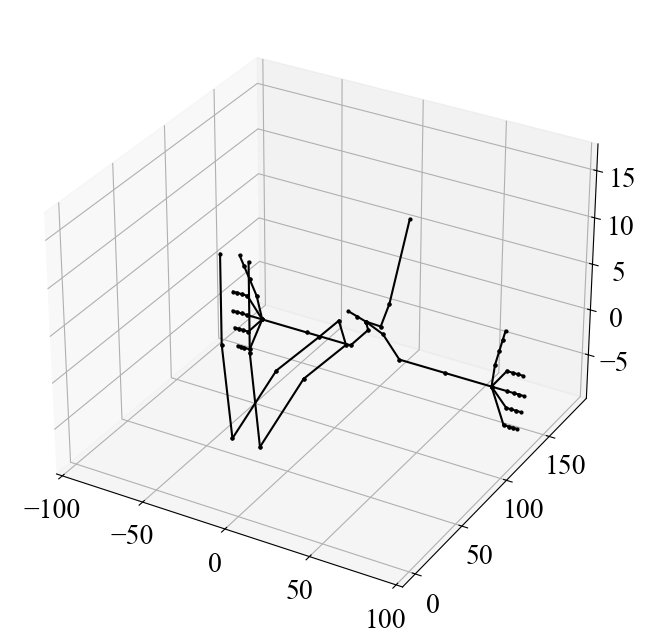

In [6]:
anim= bvhsdk.ReadFile(bvh_path1)
ani = bvhsdk.plotanimation.plot3d(anim,skiproot=2, frameDelay=10)

In [13]:
import cv2

def probe_indices(max_index=10):
    good = []
    for i in range(max_index):
        cap = cv2.VideoCapture(i)
        ok = cap.isOpened()
        if ok:
            good.append(i)
        cap.release()
    return good

probe_indices()

OpenCV: out device of bound (0-1): 2
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 3
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 4
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 5
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 6
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 7
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 8
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 9
OpenCV: camera failed to properly initialize!


[0, 1]

In [14]:
import cv2, time
from IPython.display import display
import ipywidgets as widgets

INDEX_TO_TRY = [1, 0]  # try 1 first if your Sony is likely the second device
WIDTH, HEIGHT, FPS_LIMIT = 1280, 720, 30

def open_avf(index):
    cap = cv2.VideoCapture(index, cv2.CAP_AVFOUNDATION)
    if not cap.isOpened():
        return None
    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  WIDTH)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, HEIGHT)
    return cap

cap = None
picked = None
for i in INDEX_TO_TRY:
    c = open_avf(i)
    if c and c.read()[0]:
        cap, picked = c, i
        break

if cap is None:
    raise RuntimeError("Could not read from indices 0 or 1 with AVFoundation. "
                       "Close Zoom/OBS/Teams/FaceTime and try again.")

print(f"✅ Using device index {picked} (AVFoundation). Press the stop button or interrupt the cell to quit.")

img_w = widgets.Image(format='jpeg')
display(img_w)

try:
    last = 0.0
    while True:
        ok, frame = cap.read()
        if not ok:
            print("⚠️ Frame read failed. Is another app using the camera?")
            break
        ok, buf = cv2.imencode(".jpg", frame)
        if ok: img_w.value = buf.tobytes()
        # basic fps cap
        dt = 1.0/FPS_LIMIT
        now = time.time()
        time.sleep(max(0, dt - (now-last)))
        last = time.time()
except KeyboardInterrupt:
    print("⏹️ Stopped.")
finally:
    cap.release()

✅ Using device index 1 (AVFoundation). Press the stop button or interrupt the cell to quit.


Image(value=b'', format='jpeg')

⏹️ Stopped.


In [2]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install opencv-python ipywidgets ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 55.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 772.7/772.7 kB 30.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.0/36.0 MB 60.0 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: torch90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/7 [polars-runtime-32]
    Found existing installation: torch 2.8.0━━━━━━━━━━━━━━━━━━ 1/7 [polars-runtime-32]
    Uninstalling torch-2.8.0:━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/7 [torch]time-32]
      Successfully uninstalled torch-2.8.0━━━━━━━━━━━━━━━━━━━━ 2/7 [torch]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [ultralytics] [ultralytics]


In [1]:
import cv2, time
from IPython.display import display
import ipywidgets as widgets

WIDTH, HEIGHT, FPS_LIMIT = 1280, 720, 30

def open_avfoundation(index):
    cap = cv2.VideoCapture(index, cv2.CAP_AVFOUNDATION)
    if not cap.isOpened():
        return None
    # Try to request a resolution (driver may choose closest)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  WIDTH)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, HEIGHT)
    ok, _ = cap.read()
    if not ok:
        cap.release()
        return None
    return cap

# Try 1 then 0
cap = open_avfoundation(0)
if cap is None:
    raise RuntimeError(
        "Could not read from indices 1 or 0 with AVFoundation.\n"
        "Close Zoom/OBS/FaceTime/etc., check macOS Camera permission for your Jupyter app/terminal, "
        "and confirm the Sony is in USB Streaming mode or routed via a capture card."
    )

print("✅ Streaming. Interrupt the cell (stop button) to quit.")
img_w = widgets.Image(format='jpeg')
display(img_w)

try:
    last = 0.0
    while True:
        ok, frame = cap.read()
        if not ok:
            print("⚠️ Frame read failed (camera busy?).")
            break
        ok, jpg = cv2.imencode(".jpg", frame)
        if ok:
            img_w.value = jpg.tobytes()
        # simple FPS limiter
        now = time.time()
        wait = (1.0 / FPS_LIMIT) - (now - last)
        if wait > 0: time.sleep(wait)
        last = time.time()
except KeyboardInterrupt:
    print("⏹️ Stopped.")
finally:
    cap.release()

2025-10-21 10:20:39.391 Python[80261:14893862] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


✅ Streaming. Interrupt the cell (stop button) to quit.


Image(value=b'', format='jpeg')

⏹️ Stopped.


In [1]:
# In JupyterLab this is usually not needed; in classic Notebook run once:
import sys, subprocess, json

In [2]:
import cv2, time

CAM_INDEX = 0     # your ILCE-7M4 per ffmpeg listing
WIDTH, HEIGHT = 1280, 720   # start at 720p; you can switch to 1920x1080 later

def open_camera(index=CAM_INDEX, width=WIDTH, height=HEIGHT):
    cap = cv2.VideoCapture(index, cv2.CAP_AVFOUNDATION)
    if not cap.isOpened():
        raise RuntimeError("Could not open camera. Close Zoom/OBS/etc. and replug the Sony.")
    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  width)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
    ok, _ = cap.read()
    if not ok:
        cap.release()
        raise RuntimeError("Camera opened but no frames. Another app may be using it.")
    return cap

In [3]:
from ultralytics import YOLO

# 'yolov8n' is tiny & fast; swap to 'yolov8s'/'m' if you want higher accuracy
yolo = YOLO("yolov8n.pt")   # first run downloads weights

In [7]:
import sys
!{sys.executable} -m pip install opencv-python mediapipe python-osc ipywidgets numpy

  Using cached protobuf-4.25.8-cp37-abi3-macosx_10_9_universal2.whl.metadata (541 bytes)
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.


  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 MB 58.5 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 50.6 MB/s  0:00:00 eta 0:00:01
Using cached protobuf-4.25.8-cp37-abi3-macosx_10_9_universal2.whl (394 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 56.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 MB 58.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 MB 57.2 MB/s  0:00:00 eta 0:00:01
Using cached opt_einsum-3.4.0-py3-none-any.whl (71 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.3 MB/s  0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.32.1
    Uninstalling protobuf-6.32.1:
      Successfully uninstall